# Break test: a Toyota Land Cruiser HJ60 braking, recorded by five SmartSolo nodes

The data in `data/break_test/` are the seismic signal of a **Toyota Land Cruiser HJ60 that brakes – with a laughing baby in the back seat** (about ten braking manoeuvres, exact times not noted). Five IGU-16HR 3C 5 Hz nodes (project `UTASTesting`, firmware V1.0.5.6, 500 sps, 0 dB gain) recorded on **31 March 2023, 01:28–02:00 UTC (12:28–13:00 AEDT)** along a road beside the sports oval in Sandy Bay, Hobart (`seis000` files).

Everything below is read straight from the raw DLD files with `smartsolo_dld` (times from GPS time of week, see `dld_demo.ipynb`). The raw files are in Git LFS – run `git lfs pull` after cloning.

In [1]:
import sys; sys.path.insert(0, "../lib")
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.dates as mdates
from scipy.signal import hilbert, find_peaks, welch
from obspy import UTCDateTime, Stream
import geopandas as gpd, contextily as cx
import smartsolo_dld as dld, smartsolo_log as sl, smartsolo_locate as loc, smartsolo_node as sn, smartsolo_orientation as so
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 80

BT = Path("../data/break_test")
SERIALS = sorted(p.name for p in BT.iterdir() if p.is_dir())
COL = dict(zip(SERIALS, ["C4", "C0", "C1", "C2", "C3"]))
def dld_file(serial, session=0, comp="Z"):
    return next((BT / serial).glob(f"*/seis{session:03d}{comp}.DLD"))
def read3(serial, session, t0=None, t1=None):
    st = Stream()
    for c in "XYZ":
        st += dld.read_dld(dld_file(serial, session, c), starttime=t0, endtime=t1)
    st.merge(fill_value=0)
    return st
SERIALS

['453004362', '453009194', '453010047', '453010077', '453010167']

## 1. Where were the nodes?
Positions come from the GPS fixes in the DLD time tags (one per 1000 samples = every 2 s), using the first stable position of the recording. The logs have only 2–3 fixes for this short session.

In [2]:
deps = loc.build_deployments_from_dld(BT)
deps = deps[deps.session == 0].reset_index(drop=True)
deps[["deployment_id", "start", "end", "latitude", "longitude", "elevation", "median_offset_m", "max_offset_m"]]

,deployment_id,start,end,latitude,longitude,elevation,median_offset_m,max_offset_m
0,453004362_dld000,2023-03-31 01:29:21+00:00,2023-03-31 02:00:08.998000+00:00,-42.902494,147.329289,50.700001,2.078859,192.768947
1,453009194_dld000,2023-03-31 01:30:53+00:00,2023-03-31 01:59:16.998000+00:00,-42.902451,147.329321,60.200001,1.941428,6.962423
2,453010047_dld000,2023-03-31 01:28:21+00:00,2023-03-31 01:59:08.998000+00:00,-42.902554,147.329108,40.599998,10.984079,181.479572
3,453010077_dld000,2023-03-31 01:33:23+00:00,2023-03-31 02:00:10.998000+00:00,-42.901729,147.330097,24.799999,3.441733,67.998830
4,453010167_dld000,2023-03-31 01:34:39+00:00,2023-03-31 01:58:38.998000+00:00,-42.901660,147.330208,28.900000,1.961988,80.246446


The large `max_offset_m` values are not GPS noise: the tag positions show when nodes were **picked up and carried** while still recording.

In [3]:
def moves(serial, session, tol=20):
    t = dld.read_dld_tags(dld_file(serial, session)).set_index("time")
    d = deps[(deps.serial == serial) & (deps.session == session)].iloc[0]
    r = loc.distance_m(t.latitude, t.longitude, d.latitude, d.longitude)
    moved = t.index[r > tol]
    return t, (moved[0] if len(moved) else pd.NaT)
moved_at = {s: moves(s, 0)[1] for s in SERIALS}
pd.Series(moved_at, name="first position > 20 m from install (31 Mar)")

453004362   2023-03-31 01:55:19+00:00
453009194                         NaT
453010047   2023-03-31 01:55:49+00:00
453010077   2023-03-31 01:51:57+00:00
453010167   2023-03-31 01:51:45+00:00
Name: first position > 20 m from install (31 Mar), dtype: datetime64[us, UTC]

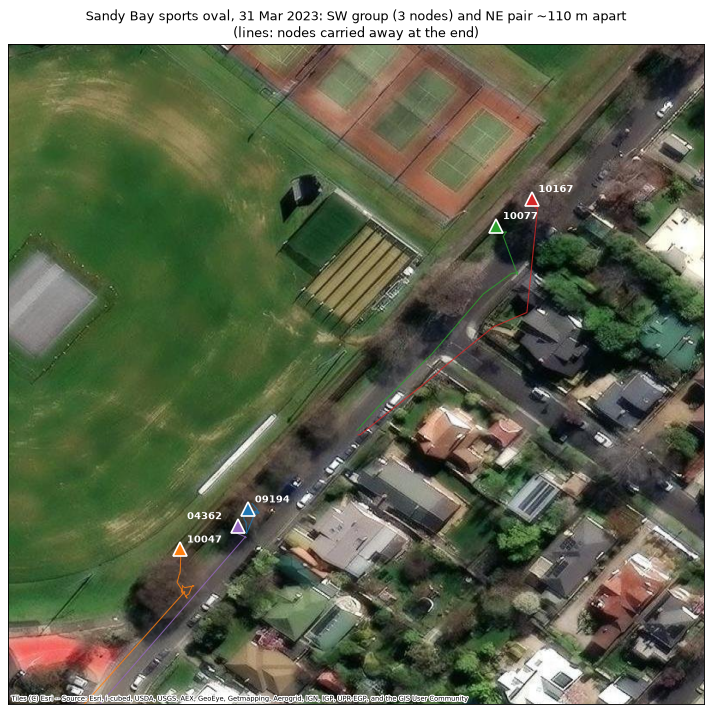

In [4]:
def site_map(ax, d, pad=40, zoom=19, title="", tracks=None):
    g = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(d.longitude, d.latitude), crs=4326).to_crs(3857)
    if tracks is not None:
        for s, tr in tracks.items():
            tg = gpd.GeoSeries(gpd.points_from_xy(tr.longitude, tr.latitude), crs=4326).to_crs(3857)
            ax.plot(tg.x, tg.y, "-", color=COL[s], lw=1, alpha=.8)
    for _, r in g.iterrows():
        ax.plot(r.geometry.x, r.geometry.y, "^", ms=12, color=COL[r.serial], mec="w", mew=1.5)
        ax.annotate(r.serial[-5:], (r.geometry.x, r.geometry.y), xytext=(-46, 6) if r.serial == "453004362" else (6, 6), textcoords="offset points",
                    color="w", fontsize=9, fontweight="bold")
    b = g.total_bounds
    ax.set_xlim(b[0] - pad, b[2] + pad); ax.set_ylim(b[1] - pad, b[3] + pad)
    cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom=zoom, attribution_size=6)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    return g

fig, ax = plt.subplots(figsize=(9, 9))
tracks = {s: moves(s, 0)[0] for s in SERIALS}
site_map(ax, deps, pad=60, title="Sandy Bay sports oval, 31 Mar 2023: SW group (3 nodes) and NE pair ~110 m apart\n(lines: nodes carried away at the end)", tracks=tracks)
plt.tight_layout()

In [5]:
d0 = deps[deps.session == 0].set_index("serial")
dist = pd.DataFrame({a: {b: loc.distance_m(d0.latitude[a], d0.longitude[a], d0.latitude[b], d0.longitude[b]) for b in SERIALS} for a in SERIALS}).round(1)
SW_GROUP = ["453009194", "453004362", "453010047"]       # 453004362 stands 5 m from 453009194
SW, NE = ["453009194", "453010047"], ["453010077", "453010167"]   # pairs used for detection (21 m and 12 m)
GROUP = {"SW": SW_GROUP, "NE": NE}
PAIR_DIST = float(np.mean([dist.loc[a, b] for a in SW for b in NE]))
print(f"pair spacing SW–NE ≈ {PAIR_DIST:.0f} m"); dist

pair spacing SW–NE ≈ 118 m


,453004362,453009194,453010047,453010077,453010167
453004362,0.0,5.4,16.2,107.6,119.2
453009194,5.4,0.0,20.7,102.3,113.9
453010047,16.2,20.7,0.0,122.1,133.9
453010077,107.6,102.3,122.1,0.0,11.9
453010167,119.2,113.9,133.9,11.9,0.0


## 2. Node health from the logs and the pulse test

In [6]:
rows = []
for s in SERIALS:
    folder = next((BT / s).iterdir())
    node = sn.read_node_folder(folder)
    df = sl.read_log(folder / "DigiSolo.LOG")
    p = node["pulse"].set_index("axis")
    qc = node["qc"]
    for ses, g in df.groupby("session"):
        if g.temperature.notna().sum() == 0 or g.index.min().date() != pd.Timestamp("2023-03-31").date():
            continue           # the logs also hold a later recording; only the 31 March power-up is used
        rows.append(dict(serial=s, session=int(ses), temp_min=g.temperature.min(), temp_max=g.temperature.max(),
                         battery_V=g.voltage.dropna().iloc[-1] if g.voltage.notna().any() else np.nan,
                         tilt=g.tilted_angle.median(), heading=so.circular_mean(g.ecompass_north.dropna() % 360),
                         geophone_ok=bool(qc[qc.boot_no == ses].ok_all.all()) if (qc.boot_no == ses).any() else None,
                         pulse_f0=p.f0_hz.mean(), pulse_h=p.damping.mean(), noise_uV=p.noise_rms_uV.mean()))
health = pd.DataFrame(rows); health.round(2)

,serial,session,temp_min,temp_max,battery_V,tilt,heading,geophone_ok,pulse_f0,pulse_h,noise_uV
0,453004362,2,17.50,19.12,8.10,4.74,151.76,True,5.01,0.73,1.25
1,453009194,2,18.06,18.75,NaN,4.19,162.40,True,4.99,0.70,1.18
2,453010047,2,17.94,19.44,7.59,3.96,121.15,False,5.00,0.70,1.15
3,453010077,2,17.81,18.75,NaN,1.70,116.28,False,5.00,0.72,1.17
4,453010167,3,18.00,19.00,NaN,11.33,95.88,True,4.96,0.72,1.18


In [7]:
allqc = pd.concat([sn.geophone_qc(sl.read_device_info(next((BT / s).iterdir()) / "DigiSolo.LOG")) for s in SERIALS])
boots = set(zip(health.serial, health.session))
bad = allqc[~allqc.ok_all & np.array([b in boots for b in zip(allqc.serial, allqc.boot_no)])]
bad[["serial", "boot_no", "channel", "resonate_freq_hz", "damping", "sensitivity", "spread_noise", "noisy"]].round(3)

,serial,boot_no,channel,resonate_freq_hz,damping,sensitivity,spread_noise,noisy
1,453010047,2,2,4.589,0.595,69.531,62897.098,True
2,453010047,2,3,5.256,0.587,71.725,144273.953,True
0,453010077,2,1,5.415,0.681,88.094,96.075,False
1,453010077,2,2,5.204,0.693,84.235,80.316,False
2,453010077,2,3,78030.836,0.017,7211.886,259.862,False


- The pulse test (`PULSE_*.WAV`, from the node's latest power-up) gives f0 ≈ 5.0 Hz, h ≈ 0.70 and a 1.2 µV noise floor on all five nodes. These nodes record at **500 sps**, yet the pulse files only make sense at 1000 sps – the pulse test has a **fixed rate, independent of the acquisition rate**.
- Two boot-time tests failed: 453010047 was moving while it tested itself (spread noise up to 144 000), and 453010077 Ch3 returned garbage (f0 = 78 kHz) without being noisy – a one-off glitch, as the node's next boot is fine.
- Temperatures 17–19 °C. 453010167 stood at **11° tilt** – beyond the 10° spec even for the vertical geophone.

## 3. The recording at a glance

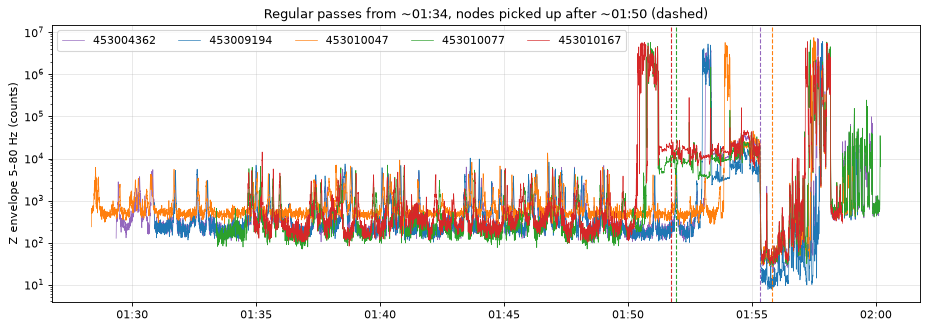

In [8]:
def envelope(tr, fmin=5, fmax=80, smooth=0.5, step=0.1):
    tr = tr.copy(); tr.detrend("demean"); tr.filter("bandpass", freqmin=fmin, freqmax=fmax)
    e = np.abs(hilbert(tr.data.astype(float)))
    k = int(smooth * tr.stats.sampling_rate); e = np.convolve(e, np.ones(k) / k, "same")
    n = int(step * tr.stats.sampling_rate)
    t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")
    return pd.Series(e[::n], index=t0 + pd.to_timedelta(np.arange(len(e[::n])) * step, unit="s"))

Z0 = {s: dld.read_dld(dld_file(s, 0))[0] for s in SERIALS}
E0 = pd.DataFrame({s: envelope(tr) for s, tr in Z0.items()})
fig, ax = plt.subplots(figsize=(14, 4.5))
for s in SERIALS:
    ax.semilogy(E0.index, E0[s], lw=.6, color=COL[s], label=s)
    if pd.notna(moved_at[s]):
        ax.axvline(moved_at[s], color=COL[s], ls="--", lw=1)
ax.set(ylabel="Z envelope 5–80 Hz (counts)", title="Regular passes from ~01:34, nodes picked up after ~01:50 (dashed)")
ax.legend(ncol=5); ax.grid(alpha=.3); ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

## 4. Detecting the vehicle events
Peaks of the envelope at least 8× the background, separated by ≥5 s, required on **both** nodes of a pair within 5 s (the outer SW nodes are 21 m apart, so a passing car reaches them a few seconds apart). 453004362, next to 453009194, is used to check the events and in the plots. Only the time the nodes were in place is used.

In [9]:
T_START = pd.Timestamp("2023-03-31 01:34:45", tz="UTC")
# stop before the nodes are handled: first envelope above 100 000 counts (handling saturates the nodes)
handled = E0[(E0 > 1e5).any(axis=1)].index
T_END = min([handled[handled > T_START][0]] + [t for t in moved_at.values() if pd.notna(t)]) - pd.Timedelta("20s")

def peaks(series, factor=8, min_sep=5.0):
    x = series.dropna(); bg = x.median()
    p, prop = find_peaks(x.values, height=factor * bg, prominence=factor / 2 * bg, distance=int(min_sep / 0.1))
    return pd.DataFrame({"time": x.index[p], "amp": prop["peak_heights"], "snr": prop["peak_heights"] / bg})

def pair_events(pair, E, tol=5.0):
    a, b = (peaks(E[s].loc[T_START:T_END]) for s in pair)
    out = []
    for _, r in a.iterrows():
        dt = (b.time - r.time).dt.total_seconds().abs()
        if len(dt) and dt.min() <= tol:
            j = dt.idxmin()
            out.append(dict(time=r.time + (b.time[j] - r.time) / 2, amp=np.sqrt(r.amp * b.amp[j]),
                            snr=np.sqrt(r.snr * b.snr[j]), dt_within_pair=(b.time[j] - r.time).total_seconds()))
    return pd.DataFrame(out)

ev_sw, ev_ne = pair_events(SW, E0), pair_events(NE, E0)
for ev, pair in [(ev_sw, SW), (ev_ne, NE)]:
    d = dist.loc[pair[0], pair[1]]
    ev["speed_within_pair_kmh"] = np.where(ev.dt_within_pair.abs() > 0.2, d / ev.dt_within_pair.abs() * 3.6, np.nan)
print(len(ev_sw), "events at the SW pair,", len(ev_ne), "at the NE pair between", T_START.strftime("%H:%M:%S"), "and", T_END.strftime("%H:%M:%S"))

9 events at the SW pair, 24 at the NE pair between 01:34:45 and 01:50:02


Matching each NE-pair event with the nearest SW-pair event (within 20 s) gives the travel time between the pairs, and with the ~110 m spacing an **apparent speed**. The sign tells the direction.

In [10]:
match = []
for _, r in ev_ne.iterrows():
    dt = (ev_sw.time - r.time).dt.total_seconds()
    if len(dt) and dt.abs().min() <= 20:
        j = dt.abs().idxmin()
        match.append(dict(time_NE=r.time, time_SW=ev_sw.time[j], dt=dt[j], amp_NE=r.amp, amp_SW=ev_sw.amp[j]))
match = pd.DataFrame(match)
match["direction"] = np.where(match.dt > 0, "NE → SW", "SW → NE")
match["speed_kmh"] = PAIR_DIST / match.dt.abs() * 3.6
match = match[match.dt.abs() > 2]          # simultaneous peaks are separate sources, not one vehicle
match.round(1)

,time_NE,time_SW,dt,amp_NE,amp_SW,direction,speed_kmh
0,2023-03-31 01:34:49.900000+00:00,2023-03-31 01:35:01.200000+00:00,11.3,5686.7,5714.9,NE → SW,37.6
1,2023-03-31 01:35:12.500000+00:00,2023-03-31 01:35:01.200000+00:00,-11.3,9673.5,5714.9,SW → NE,37.6
2,2023-03-31 01:38:18.550000+00:00,2023-03-31 01:38:36.700000+00:00,18.2,3021.8,6014.7,NE → SW,23.4
3,2023-03-31 01:38:24.450000+00:00,2023-03-31 01:38:36.700000+00:00,12.2,5149.3,6014.7,NE → SW,34.7
4,2023-03-31 01:39:01.500000+00:00,2023-03-31 01:38:50.100000+00:00,-11.4,4835.0,6411.5,SW → NE,37.3
5,2023-03-31 01:40:35.300000+00:00,2023-03-31 01:40:48.700000+00:00,13.4,3492.7,7950.1,NE → SW,31.7
6,2023-03-31 01:40:42.350000+00:00,2023-03-31 01:40:48.700000+00:00,6.4,3977.1,7950.1,NE → SW,66.9
7,2023-03-31 01:40:58.250000+00:00,2023-03-31 01:40:48.700000+00:00,-9.6,6556.3,7950.1,SW → NE,44.5
8,2023-03-31 01:43:48.850000+00:00,2023-03-31 01:43:40+00:00,-8.8,4968.0,9178.7,SW → NE,48.0
9,2023-03-31 01:45:02.100000+00:00,2023-03-31 01:44:51.300000+00:00,-10.8,5495.6,6017.6,SW → NE,39.3


median apparent speed 40 km/h, 14 matched passes


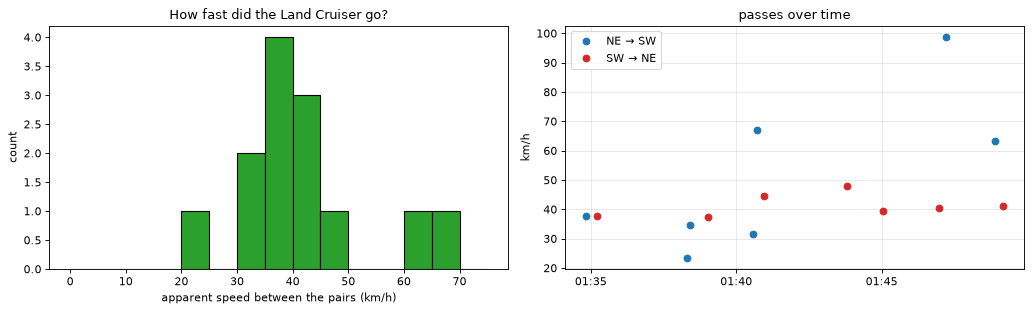

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(match.speed_kmh, bins=np.arange(0, 80, 5), color="C2", ec="k")
axes[0].set(xlabel="apparent speed between the pairs (km/h)", ylabel="count", title="How fast did the Land Cruiser go?")
for d, c in [("NE → SW", "C0"), ("SW → NE", "C3")]:
    m = match[match.direction == d]
    axes[1].plot(m.time_NE, m.speed_kmh, "o", color=c, label=d)
axes[1].set(ylabel="km/h", title="passes over time"); axes[1].legend(); axes[1].grid(alpha=.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); plt.tight_layout()
print(f"median apparent speed {match.speed_kmh.median():.0f} km/h, {len(match)} matched passes")

In [12]:
print("speed from the delay between the two nodes of a pair (km/h):")
pd.concat([ev_sw.assign(pair="SW"), ev_ne.assign(pair="NE")]).groupby("pair").speed_within_pair_kmh.describe().round(0)

speed from the delay between the two nodes of a pair (km/h):


,count,mean,std,min,25%,50%,75%,max
pair,,,,,,,,
NE,23.0,53.0,27.0,11.0,34.0,48.0,71.0,143.0
SW,9.0,25.0,3.0,19.0,25.0,25.0,27.0,29.0


Most passes come out at a gentle 20–40 km/h between the pairs – a car that slows down, stops and goes again, rather than one cruising through (a car braking *between* the pairs also stretches the travel time and lowers the apparent speed). The delay between the two nodes *within* a pair (12 and 21 m apart) gives a second, local speed: events with several seconds between the two nodes are the car crawling or stopping right there. Treat individual values with care: other vehicles on the road produce peaks too.

## 5. Ten candidate brake stops
The strongest events at each pair – in a braking test the car stops close to the sensors, so these are the most likely brake stops.

In [13]:
top = pd.concat([ev_sw.assign(pair="SW"), ev_ne.assign(pair="NE")]).sort_values("snr", ascending=False).head(10)
top = top.sort_values("time").reset_index(drop=True); top.index += 1
top.round(1)

,time,amp,snr,dt_within_pair,speed_within_pair_kmh,pair
1,2023-03-31 01:34:49.900000+00:00,5686.7,20.4,-0.8,53.6,NE
2,2023-03-31 01:35:12.500000+00:00,9673.5,34.7,4.0,10.7,NE
3,2023-03-31 01:38:24.450000+00:00,5149.3,18.5,-0.9,47.6,NE
4,2023-03-31 01:40:48.700000+00:00,7950.1,19.2,-2.6,28.7,SW
5,2023-03-31 01:40:58.250000+00:00,6556.3,23.5,0.3,142.8,NE
6,2023-03-31 01:43:40+00:00,9178.7,22.2,4.0,18.6,SW
7,2023-03-31 01:45:02.100000+00:00,5495.6,19.7,1.2,35.7,NE
8,2023-03-31 01:46:47+00:00,10585.0,25.6,-3.0,24.8,SW
9,2023-03-31 01:46:57.500000+00:00,5998.2,21.5,0.6,71.4,NE
10,2023-03-31 01:49:10.650000+00:00,5450.7,19.5,0.7,61.2,NE


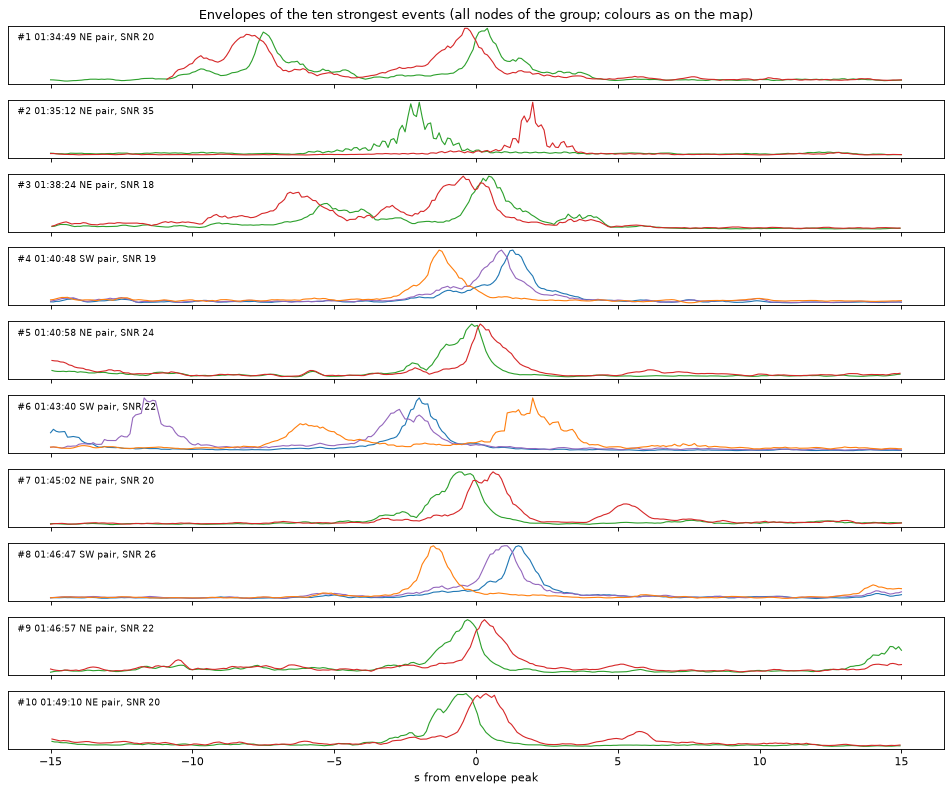

In [14]:
fig, axes = plt.subplots(len(top), 1, figsize=(12, 1.0 * len(top)), sharex=True)
for ax, (i, r) in zip(axes, top.iterrows()):
    for s in GROUP[r.pair]:
        x = E0[s].loc[r.time - pd.Timedelta("15s"): r.time + pd.Timedelta("15s")]
        ax.plot((x.index - r.time).total_seconds(), x / x.max(), color=COL[s], lw=1)
    ax.text(0.01, 0.75, f"#{i} {r.time:%H:%M:%S} {r.pair} pair, SNR {r.snr:.0f}", transform=ax.transAxes, fontsize=8)
    ax.set_yticks([])
axes[-1].set_xlabel("s from envelope peak"); axes[0].set_title("Envelopes of the ten strongest events (all nodes of the group; colours as on the map)")
plt.tight_layout()

## 6. One event up close: record section and spectrogram

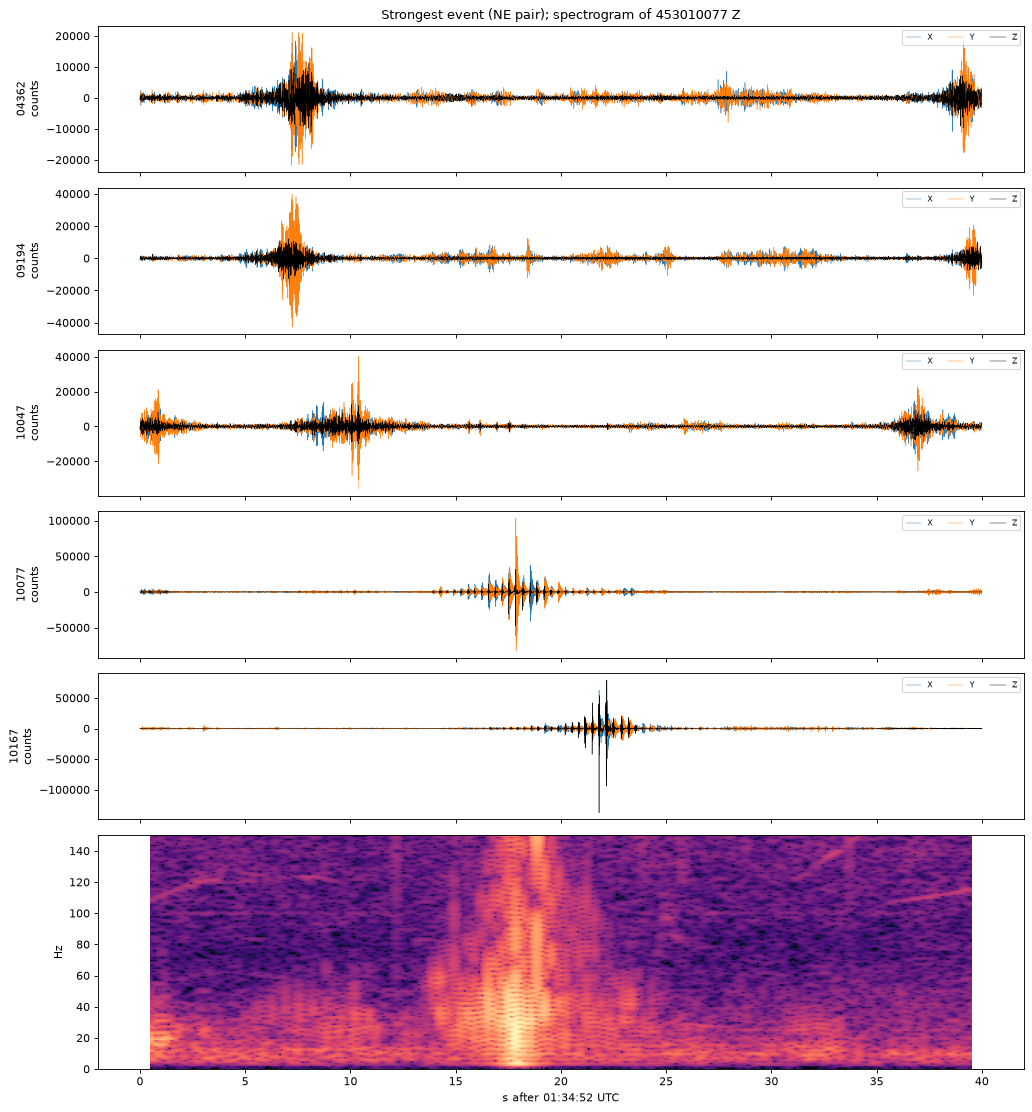

In [15]:
EV = top.iloc[np.argmax(top.snr.values)]
t0, t1 = UTCDateTime(EV.time.to_pydatetime()) - 20, UTCDateTime(EV.time.to_pydatetime()) + 20
fig, axes = plt.subplots(6, 1, figsize=(13, 14), sharex=True, gridspec_kw=dict(height_ratios=[1, 1, 1, 1, 1, 1.6]))
for ax, s in zip(axes, SERIALS):
    st = read3(s, 0, t0, t1); st.detrend("demean"); st.filter("bandpass", freqmin=5, freqmax=120)
    for tr, c in zip(st, ["C0", "C1", "k"]):
        ax.plot(tr.times(), tr.data, lw=.4, color=c, label=tr.stats.channel)
    ax.set_ylabel(f"{s[-5:]}\ncounts"); ax.legend(loc="upper right", fontsize=7, ncol=3)
z = read3(EV.pair == "SW" and SW[0] or NE[0], 0, t0, t1).select(channel="Z")[0]
axes[5].specgram(z.data.astype(float) - z.data.mean(), Fs=500, NFFT=512, noverlap=480, cmap="magma", vmin=-20)
axes[5].set(ylim=(0, 150), ylabel="Hz", xlabel=f"s after {t0.strftime('%H:%M:%S')} UTC")
axes[0].set_title(f"Strongest event ({EV.pair} pair); spectrogram of {(SW if EV.pair == 'SW' else NE)[0]} Z")
plt.tight_layout()

The spectrogram shows a broadband burst when the vehicle is closest (tyres on the road, suspension, braking) and **gliding tonal lines** before and after it: engine and drivetrain tones, Doppler-shifted and changing with engine speed. The X/Y/Z traces are raw counts in the node frame (X ≈ N–S, Y ≈ E–W of the node's arrow; raw SmartSolo polarity).

## 7. Average event: stack and spectrum

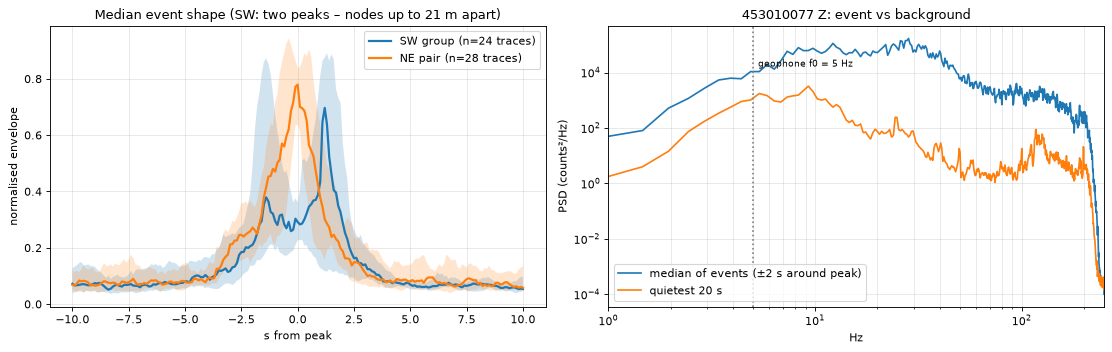

In [16]:
def stack(pair, events, half=10):
    rows = []
    for _, r in events.iterrows():
        for s in pair:
            x = E0[s].loc[r.time - pd.Timedelta(seconds=half): r.time + pd.Timedelta(seconds=half)].values
            if len(x) == int(2 * half / 0.1) + 1:
                rows.append(x / x.max())
    return np.array(rows)
tt = np.linspace(-10, 10, 201)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for pair, ev, name in [(SW_GROUP, ev_sw, "SW"), (NE, ev_ne, "NE")]:
    S = stack(pair, ev)
    axes[0].plot(tt, np.median(S, 0), lw=2, label=f"{name} {'group' if name == 'SW' else 'pair'} (n={len(S)} traces)")
    axes[0].fill_between(tt, *np.percentile(S, [25, 75], 0), alpha=.2)
axes[0].set(xlabel="s from peak", ylabel="normalised envelope", title="Median event shape (SW: two peaks – nodes up to 21 m apart)"); axes[0].legend(); axes[0].grid(alpha=.3)

def psd(tr, t0, t1):
    x = tr.slice(UTCDateTime(t0.to_pydatetime()), UTCDateTime(t1.to_pydatetime())).data.astype(float)
    return welch(x - x.mean(), fs=500, nperseg=1024)
s = NE[0]; tr = Z0[s]
evw = [psd(tr, r.time - pd.Timedelta("2s"), r.time + pd.Timedelta("2s"))[1] for _, r in ev_ne.iterrows()]
f, _ = psd(tr, ev_ne.time.iloc[0] - pd.Timedelta("2s"), ev_ne.time.iloc[0] + pd.Timedelta("2s"))
quiet_t = E0[s].loc[T_START:T_END].nsmallest(1).index[0]
fq, pq = psd(tr, quiet_t - pd.Timedelta("10s"), quiet_t + pd.Timedelta("10s"))
axes[1].loglog(f, np.median(evw, 0), label="median of events (±2 s around peak)")
axes[1].loglog(fq, pq, label="quietest 20 s")
axes[1].axvline(5, color="grey", ls=":"); axes[1].text(5.3, axes[1].get_ylim()[1] / 30, "geophone f0 = 5 Hz", fontsize=8)
axes[1].set(xlabel="Hz", ylabel="PSD (counts²/Hz)", xlim=(1, 250), title=f"{s} Z: event vs background"); axes[1].legend(); axes[1].grid(alpha=.3, which="both")
plt.tight_layout()

## 8. Particle motion: where does the energy come from?
Horizontal particle motion (X, Y in the node frame) during the strongest event, for each node. Linear motion points towards (or away from) the source; the compass reading is shown for each node, but whether the nodes were aligned with north is not known (see `smartsolo_orientation`).

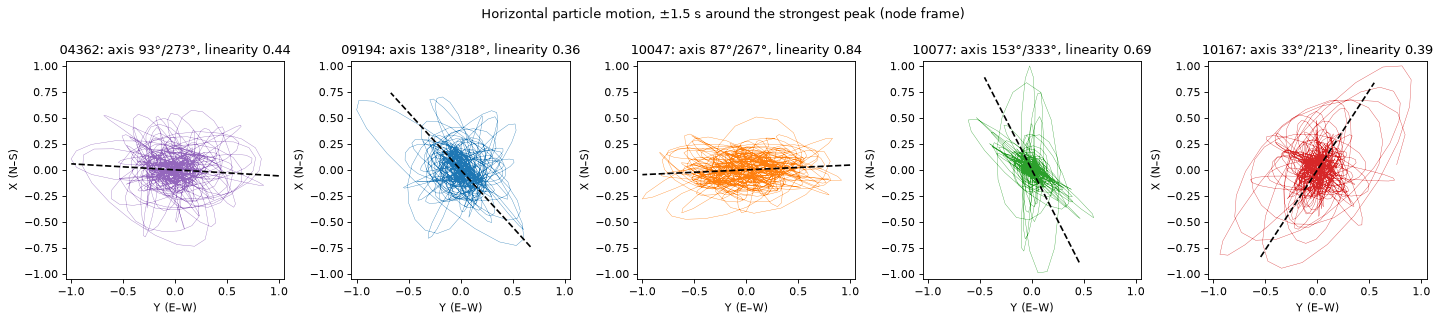

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, s in zip(axes, SERIALS):
    st = read3(s, 0, UTCDateTime(EV.time.to_pydatetime()) - 1.5, UTCDateTime(EV.time.to_pydatetime()) + 1.5)
    st.detrend("demean"); st.filter("bandpass", freqmin=5, freqmax=40)
    x, y = st.select(channel="Y")[0].data, st.select(channel="X")[0].data     # E-W, N-S
    m = max(abs(x).max(), abs(y).max())
    ax.plot(x / m, y / m, lw=.3, color=COL[s])
    # principal direction
    w, v = np.linalg.eigh(np.cov(np.vstack([x, y])))
    az = np.degrees(np.arctan2(v[0, -1], v[1, -1])) % 180
    lin = 1 - w[0] / w[1]
    ax.plot([-v[0, -1], v[0, -1]], [-v[1, -1], v[1, -1]], "k--")
    ax.set(aspect="equal", xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), xlabel="Y (E–W)", ylabel="X (N–S)",
           title=f"{s[-5:]}: axis {az:.0f}°/{az+180:.0f}°, linearity {lin:.2f}")
plt.suptitle("Horizontal particle motion, ±1.5 s around the strongest peak (node frame)"); plt.tight_layout()

## 9. Fun extras

### 9a. What was the engine doing?
The HJ60 has a 4-litre straight-six diesel (2H). A four-stroke six fires three times per crankshaft revolution, so a firing tone at *f* Hz means **rpm = 20 · f**. The strongest spectral line between 20 and 60 Hz in the seconds around each candidate brake stop:

In [18]:
rpm = []
for i, r in top.iterrows():
    s = (SW if r.pair == "SW" else NE)[0]
    for when, off in [("approach", -6), ("stopped?", +6)]:
        f, p = psd(Z0[s], r.time + pd.Timedelta(seconds=off) - pd.Timedelta("2s"), r.time + pd.Timedelta(seconds=off) + pd.Timedelta("2s"))
        band = (f > 20) & (f < 60)
        fpk = f[band][np.argmax(p[band])]
        rpm.append(dict(event=i, when=when, line_Hz=fpk, rpm=20 * fpk))
rpm = pd.DataFrame(rpm).pivot(index="event", columns="when", values="rpm")
print("estimated engine speed (rpm) if the line is the firing frequency:"); rpm.round(0)

estimated engine speed (rpm) if the line is the firing frequency:


when,approach,stopped?
event,,
1,615.0,508.0
2,703.0,557.0
3,439.0,527.0
4,410.0,459.0
5,488.0,420.0
6,400.0,488.0
7,498.0,889.0
8,430.0,508.0
9,508.0,742.0


In [19]:
print(f"median {np.nanmedian(rpm.values):.0f} rpm, range {np.nanmin(rpm.values):.0f}–{np.nanmax(rpm.values):.0f} rpm")

median 503 rpm, range 400–889 rpm


A 2H diesel idles at roughly 650 rpm. Most estimates are at or below that – so either the Land Cruiser was idling gently at each stop, or the strongest line is not the firing frequency at all (it could be half of it, a building, a pump or another car). For entertainment only.

### 9b. Searching for the laughing baby
Baby laughter comes in bursts of "ha" syllables at about **4–5 per second**, with a voice pitch of 300–600 Hz. The pitch is above the nodes' Nyquist frequency (250 Hz) and a baby on the back seat hardly shakes the road, so the only hope is the *rhythm*: a 4–5 Hz modulation of the high-frequency envelope.

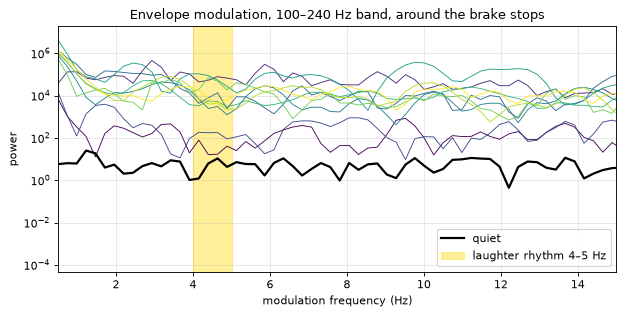

In [20]:
def modulation_spectrum(tr, t0, t1):
    x = tr.slice(UTCDateTime(t0.to_pydatetime()), UTCDateTime(t1.to_pydatetime())).copy()
    x.detrend("demean"); x.filter("bandpass", freqmin=100, freqmax=240)
    e = np.abs(hilbert(x.data.astype(float))); e = e - e.mean()
    return welch(e, fs=500, nperseg=2048)
s = NE[0]
fig, ax = plt.subplots(figsize=(9, 4))
for (_, r), c in zip(top.iterrows(), plt.cm.viridis(np.linspace(0, 1, len(top)))):
    f, p = modulation_spectrum(Z0[(SW if r.pair == "SW" else NE)[0]], r.time - pd.Timedelta("4s"), r.time + pd.Timedelta("4s"))
    ax.semilogy(f, p, color=c, lw=.8)
f, p = modulation_spectrum(Z0[s], quiet_t - pd.Timedelta("4s"), quiet_t + pd.Timedelta("4s"))
ax.semilogy(f, p, "k", lw=2, label="quiet")
ax.axvspan(4, 5, color="gold", alpha=.4, label="laughter rhythm 4–5 Hz")
ax.set(xlim=(0.5, 15), xlabel="modulation frequency (Hz)", ylabel="power", title="Envelope modulation, 100–240 Hz band, around the brake stops")
ax.legend(); ax.grid(alpha=.3)

**Result:** no peak stands out in the 4–5 Hz band – the baby's laughter is not resolved. The geophones respectfully note that the car was louder than the baby, the Nyquist frequency is 250 Hz, and laughter is an airborne signal. A future experiment could add a microphone (or a node on the back seat).

### 9c. Listen to it
The strongest event, played 20× faster (500 sps → 10 kHz) so the ground motion becomes audible: rumble of the approach, the burst of the stop, and the engine pulling away.

In [21]:
from IPython.display import Audio
z = read3((SW if EV.pair == "SW" else NE)[0], 0, UTCDateTime(EV.time.to_pydatetime()) - 15, UTCDateTime(EV.time.to_pydatetime()) + 15).select(channel="Z")[0]
z.detrend("demean"); z.filter("highpass", freq=3)
a = z.data.astype(float); a = a / np.abs(a).max()
import scipy.io.wavfile as wavfile
Path("../output").mkdir(exist_ok=True)
wavfile.write("../output/break_test_event_x20.wav", 10000, (a * 32767 * 0.9).astype(np.int16))
Audio(a, rate=10000)

## Summary
- Five nodes along a road beside the Sandy Bay sports oval on 31 March 2023, read directly from the raw DLD files: a group of three in the SW (453004362 next to 453009194) and a pair ~110 m to the NE.
- Dozens of vehicle events between 01:34 and ~01:50 UTC, seen coherently by both nodes of a pair. Matching events between the SW and NE nodes gives apparent speeds of mostly 20–40 km/h, consistent with a car slowing, stopping and pulling away. The ten strongest events are the most likely brake stops.
- Events show a broadband burst at closest approach and Doppler-gliding engine tones.
- The nodes were picked up and carried while recording after ~01:50 – visible both in the seismograms and in the GPS positions of the DLD tags.
- The laughing baby was not detected (Nyquist 250 Hz; airborne). Geophones fine apart from a test taken while moving and one test glitch; one node tilted 11°.